Selected Image: 90f6e771-bfb7-4e54-aa8c-6e295af7dc6e___Crnl_L.Mold 8761.JPG
Actual Class: Tomato___Leaf_Mold
Disease Percentage: 19.31 %
Status: INFECTED


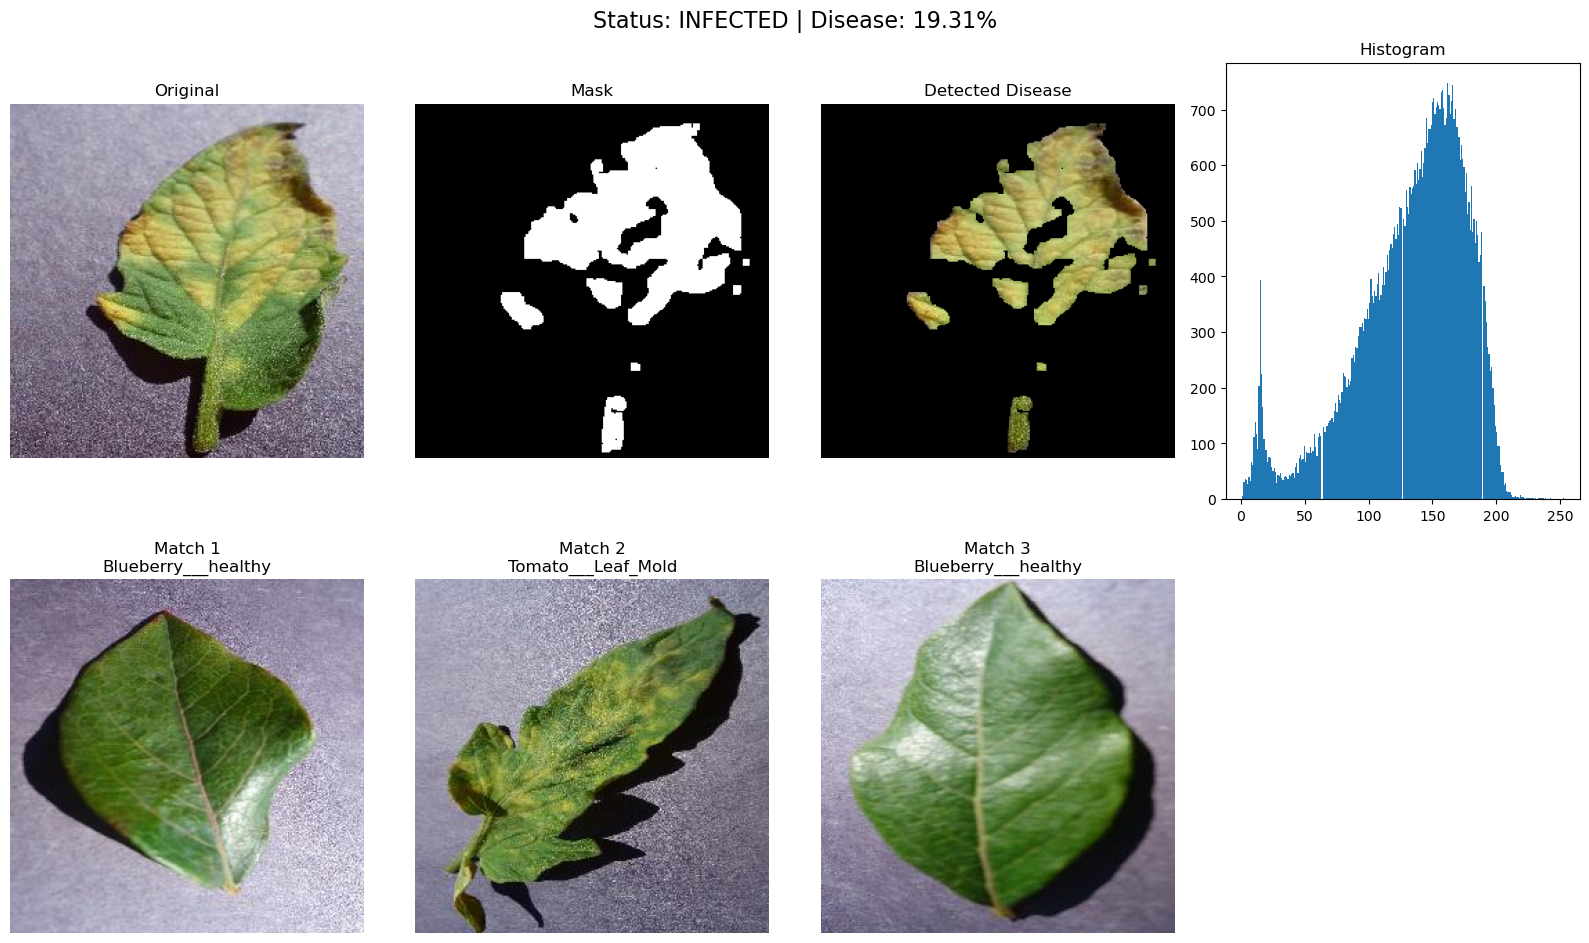

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random
dataset_path = r"C:\Users\91739\Downloads\PlantVillage-Dataset-master\PlantVillage-Dataset-master\raw\color"
folder = random.choice(os.listdir(dataset_path))
folder_path = os.path.join(dataset_path, folder)
image_name = random.choice(os.listdir(folder_path))
image_path = os.path.join(folder_path, image_name)
print("Selected Image:", image_name)
print("Actual Class:", folder)

image = cv2.imread(image_path)

if image is None:
    print("Error loading image")
    exit()
image = cv2.resize(image, (256, 256))
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
lower = np.array([10, 50, 50])
upper = np.array([35, 255, 255])
mask = cv2.inRange(hsv, lower, upper)
kernel = np.ones((5,5), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
result = cv2.bitwise_and(image_rgb, image_rgb, mask=mask)
total_pixels = image.shape[0] * image.shape[1]
disease_pixels = np.count_nonzero(mask)
percentage = (disease_pixels / total_pixels) * 100
print("Disease Percentage:", round(percentage, 2), "%")
threshold = 5
if percentage > threshold:
    status = "INFECTED"
else:
    status = "HEALTHY"

print("Status:", status)
def get_histogram(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([hsv], [0,1], None, [50,60], [0,180,0,256])
    cv2.normalize(hist, hist)
    return hist

input_hist = get_histogram(image)
similar_images = []
for folder_name in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder_name)
    
    for file in os.listdir(folder_path)[:10]: 
        path = os.path.join(folder_path, file)
        img = cv2.imread(path)
        if img is None:
            continue
        img = cv2.resize(img, (256,256))
        hist = get_histogram(img)
        score = cv2.compareHist(input_hist, hist, cv2.HISTCMP_CORREL)
        similar_images.append((score, path, folder_name))
similar_images = sorted(similar_images, reverse=True)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.figure(figsize=(16,10))
plt.subplot(2,4,1)
plt.imshow(image_rgb)
plt.title("Original")
plt.axis("off")

# Mask
plt.subplot(2,4,2)
plt.imshow(mask, cmap='gray')
plt.title("Mask")
plt.axis("off")

# Result
plt.subplot(2,4,3)
plt.imshow(result)
plt.title("Detected Disease")
plt.axis("off")

# Histogram
plt.subplot(2,4,4)
plt.hist(gray.ravel(), bins=256)
plt.title("Histogram")

# Similar Images
for i in range(3):
    img = cv2.imread(similar_images[i][1])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,4,5+i)
    plt.imshow(img)
    plt.title(f"Match {i+1}\n{similar_images[i][2]}")
    plt.axis("off")

# Title
plt.suptitle(f"Status: {status} | Disease: {round(percentage,2)}%", fontsize=16)

plt.tight_layout()
plt.show()